In [1]:
!pip install numpy
!pip install matplotlib

In [2]:
pip install numpy==1.26 librosa matplotlib

In [3]:
import numpy as np
print(np.__version__)

1.26.0


In [4]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

def create_spectrogram(audio_file, image_file):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

    y, sr = librosa.load(audio_file)
    ms = librosa.feature.melspectrogram(y=y, sr=sr)  # Use keyword arguments
    log_ms = librosa.power_to_db(ms, ref=np.max)
    librosa.display.specshow(log_ms, sr=sr, x_axis='time', y_axis='mel')

    fig.savefig(image_file)
    plt.close(fig)

def create_pngs_from_wavs(input_path, output_path):
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    
    dir = os.listdir(input_path)

    for i, file in enumerate(dir):
        if file.endswith('.wav'):  # Ensure only .wav files are processed
            input_file = os.path.join(input_path, file)
            output_file = os.path.join(output_path, file.replace('.wav', '.png'))
            create_spectrogram(input_file, output_file)

In [5]:
input_folder = r"C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\wingbeat4class\AedesAegypti"
output_folder = r"C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\spectogram4class\specaegypti"

create_pngs_from_wavs(input_folder, output_folder)

In [6]:
input_folder = r"C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\wingbeat4class\AedesAlbopictus"
output_folder = r"C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\spectogram4class\specalbopictus"

create_pngs_from_wavs(input_folder, output_folder)

In [7]:
input_folder = r"C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\wingbeat4class\Noise"
output_folder = r"C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\spectogram4class\specnoise"

create_pngs_from_wavs(input_folder, output_folder)

In [8]:
input_folder = r"C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\wingbeat4class\Others"
output_folder = r"C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\spectogram4class\specothers"

create_pngs_from_wavs(input_folder, output_folder)


In [9]:
from keras.preprocessing import image

def load_images_from_path(path, label):
    images = []
    labels = []

    for file in os.listdir(path):
        images.append(image.img_to_array(image.load_img(os.path.join(path, file), target_size=(224, 224, 3))))
        labels.append((label))
        
    return images, labels

def show_images(images):
    fig, axes = plt.subplots(1, 8, figsize=(20, 20), subplot_kw={'xticks': [], 'yticks': []})

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i] / 255)
        
x = []
y = []

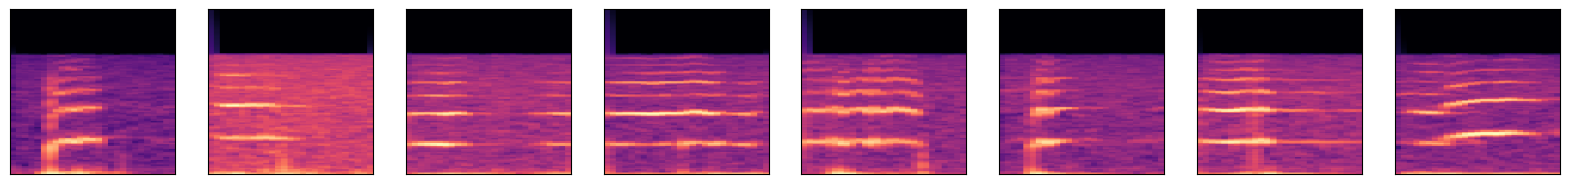

In [10]:
images, labels = load_images_from_path(r'C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\spectogram4class\specaegypti', 0)
show_images(images)

x += images
y += labels

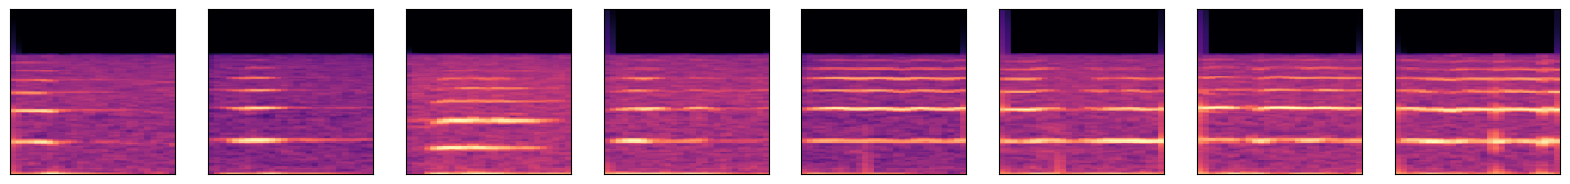

In [11]:
images, labels = load_images_from_path(r'C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\spectogram4class\specalbopictus', 1)
show_images(images)

x += images
y += labels

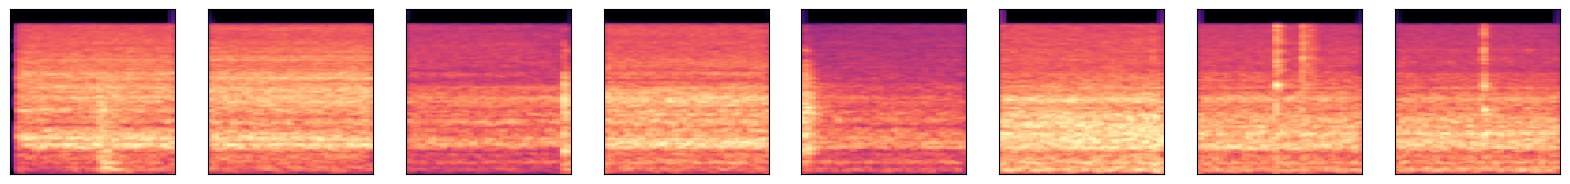

In [12]:
images, labels = load_images_from_path(r'C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\spectogram4class\specnoise', 2)
show_images(images)

x += images
y += labels

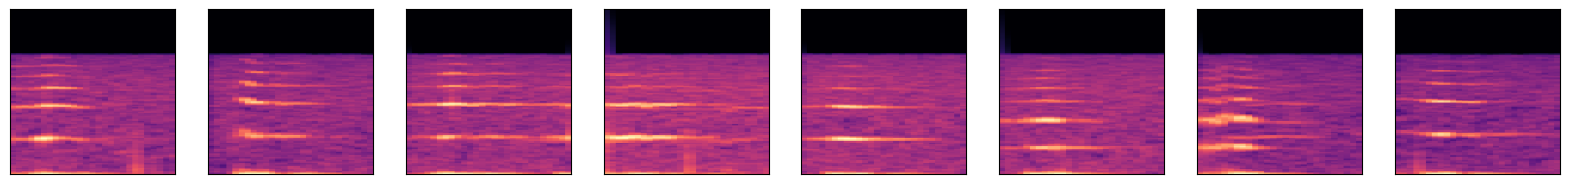

In [13]:
images, labels = load_images_from_path(r'C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\spectogram4class\specothers', 3)
show_images(images)

x += images
y += labels

In [14]:
from sklearn.model_selection import train_test_split
import numpy as np

# Convert x and y to NumPy arrays for easier manipulation
x = np.array(x)
y = np.array(y)

# Perform the 80:20 split for the entire dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Print the shapes to confirm the split
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (1302, 224, 224, 3)
Training labels shape: (1302,)
Testing data shape: (326, 224, 224, 3)
Testing labels shape: (326,)


In [15]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# One-hot encode the labels
y_train = to_categorical(y_train, num_classes=4)
y_test = to_categorical(y_test, num_classes=4)

# Print the shapes to confirm correctness
print("y_train shape after one-hot encoding:", y_train.shape)
print("y_test shape after one-hot encoding:", y_test.shape)

# Data augmentation for training
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

datagen.fit(x_train)

# Load the DenseNet121 model without the top layer
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)  # Reduced dropout
predictions = Dense(4, activation='softmax')(x)

# Create the full model
model = Model(inputs=base_model.input, outputs=predictions)

# Unfreeze the last few layers for fine-tuning
for layer in base_model.layers[-10:]:
    layer.trainable = True

# Compile the model with a smaller learning rate
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with augmented data
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    validation_data=(x_test, y_test),
    epochs=20,  # Increased epochs for better learning
    steps_per_epoch=len(x_train) // 32
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")


y_train shape after one-hot encoding: (1302, 4)
y_test shape after one-hot encoding: (326, 4)


C:\Users\USER\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1204s 24s/step - accuracy: 0.3598 - loss: 1.6034 - val_accuracy: 0.4632 - val_loss: 1.3780
Epoch 2/20
 1/40 ━━━━━━━━━━━━━━━━━━━━ 35:31 55s/step - accuracy: 0.5625 - loss: 1.0516

C:\Users\USER\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


40/40 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.5625 - loss: 1.0516 - val_accuracy: 0.4693 - val_loss: 1.3656
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 942s 23s/step - accuracy: 0.6474 - loss: 0.8091 - val_accuracy: 0.6258 - val_loss: 0.9132
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.5625 - loss: 0.8662 - val_accuracy: 0.6135 - val_loss: 0.9443
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 917s 23s/step - accuracy: 0.6978 - loss: 0.6915 - val_accuracy: 0.6963 - val_loss: 0.6153
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8125 - loss: 0.5641 - val_accuracy: 0.6902 - val_loss: 0.6160
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 893s 23s/step - accuracy: 0.6725 - loss: 0.6694 - val_accuracy: 0.7423 - val_loss: 0.5796
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.7188 - loss: 0.6121 - val_accuracy: 0.7423 - val_loss: 0.5790
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 883s 22s/step - accuracy: 0.7226 - loss: 0.6163 - val_accuracy: 0.7117 - val_loss: 0

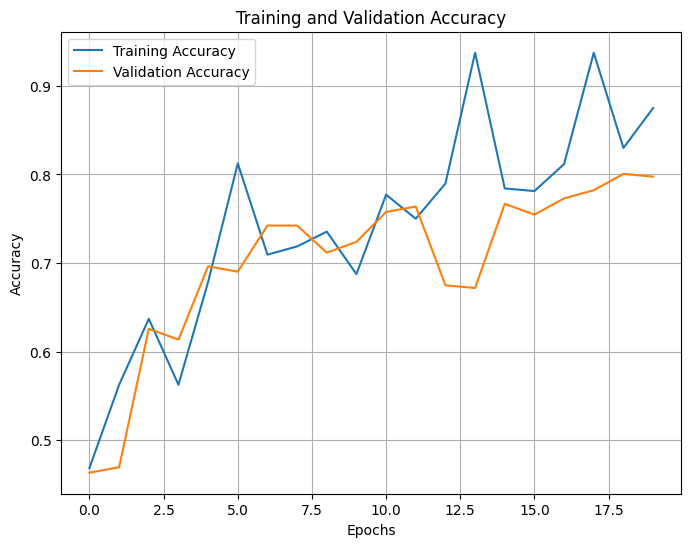

In [16]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


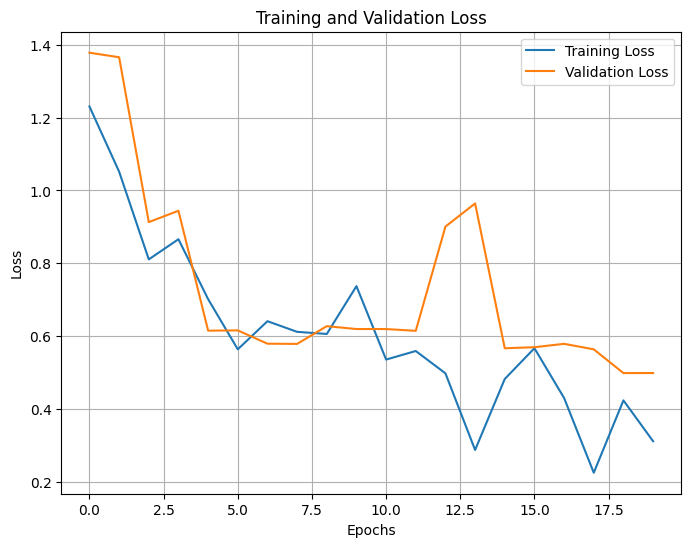

In [17]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 69s 5s/step


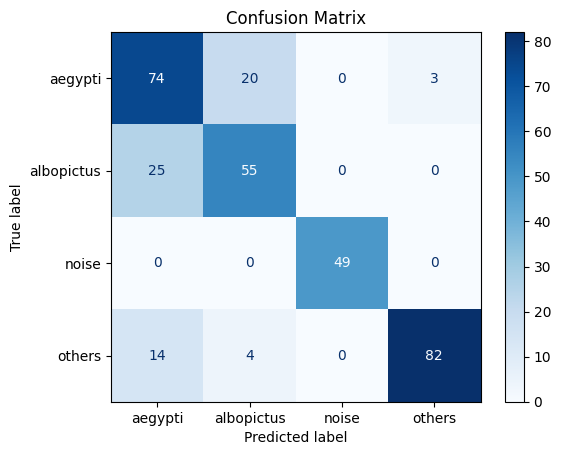

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict class probabilities for the test dataset
y_pred_probs = model.predict(x_test)

# Convert probabilities to class predictions
y_pred_classes = np.argmax(y_pred_probs, axis=1)  # Predicted labels
y_true_classes = np.argmax(y_test, axis=1)        # True labels

# Generate the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Define class labels
class_labels = ["aegypti", "albopictus", "noise", "others"]

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Confusion matrix from true labels and predicted labels
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Initialize metrics storage
num_classes = len(cm)
sensitivity = []
specificity = []
accuracy = []

# Calculate metrics for each class
for i in range(num_classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    accuracy.append((TP + TN) / np.sum(cm) if np.sum(cm) > 0 else 0)

# Display results
for i, label in enumerate(["aegypti", "albopictus", "noise", "others"]):
    print(f"Class {label}:")
    print(f"  Sensitivity: {sensitivity[i]:.2f}")
    print(f"  Specificity: {specificity[i]:.2f}")
    print(f"  Accuracy: {accuracy[i]:.2f}")
    print()

Class aegypti:
  Sensitivity: 0.76
  Specificity: 0.83
  Accuracy: 0.81

Class albopictus:
  Sensitivity: 0.69
  Specificity: 0.90
  Accuracy: 0.85

Class noise:
  Sensitivity: 1.00
  Specificity: 1.00
  Accuracy: 1.00

Class others:
  Sensitivity: 0.82
  Specificity: 0.99
  Accuracy: 0.94



In [20]:
from sklearn.metrics import classification_report

# Assuming `y_true_classes` contains true labels and `y_pred_classes` contains predicted labels
# Example:
# y_true_classes = [0, 1, 2, 3, 2, ...]  # Replace with actual true labels
# y_pred_classes = [0, 1, 2, 3, 2, ...]  # Replace with actual predicted labels

# Generate the classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=["Aegypti", "Albopictus", "Noise", "Others"])

# Print the report
print(report)

              precision    recall  f1-score   support

     Aegypti       0.65      0.76      0.70        97
  Albopictus       0.70      0.69      0.69        80
       Noise       1.00      1.00      1.00        49
      Others       0.96      0.82      0.89       100

    accuracy                           0.80       326
   macro avg       0.83      0.82      0.82       326
weighted avg       0.81      0.80      0.80       326



In [42]:
# Save the entire model (architecture + weights + optimizer state)
model.save('densenet_model.h5')
print("Model saved successfully!")


Model saved successfully!


In [44]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('densenet_model.h5')
print("Model loaded successfully!")


Model loaded successfully!
